In [182]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import defect_projector as dp
import numerical_quenches as nq 
import general_projectors as gp

from numerical_quenches import groundstate
from general_projectors import P_generic
from defect_projector import Px_n_down as P_defect
import TFIM_operators_from_states as op

In [261]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 2*np.pi, 50)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def P_defect_vector(n,sites,states):
    return array([P_defect(n,sites,s) for s in states])
def P_tilted_vector(n,nhat,states):
    return array([ P_generic(n,nhat,s) for s in states])

In [262]:
ns=[1,5,8]

In [263]:
taus_free = [.05,5,50]
print(taus_free)
g0s = [30, 10, 5, 5,5,5,5,5,5,5,5,5]
gfs = [.5]
L = 600

free_states = {}
free_times = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        states, t_eval = free_evo_states(tau, gf, g0, L)

        free_states[(tau, gf)] = states
        free_times[(tau, gf)] = t_eval

[0.05, 5, 50]
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5


In [264]:
def P_vector(n,states):
    return array([op.Px_n(n,s) for s in states])
def Pz_vector(n,states):
    return array([op.Pz_n(n,s) for s in states])

In [265]:

dat2 = {}   # Pz
dat1 = {}   # Px

for (tau, gf), states_j in free_states.items():
    dat2[(tau, gf)] = np.array([
        Pz_vector(n, states_j)
        for n in ns
    ])

for (tau, gf), states_j in free_states.items():
    dat1[(tau, gf)] = np.array([
        P_vector(n, states_j)
        for n in ns
    ])

print("Done!")

Done!


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32148/3581361306.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


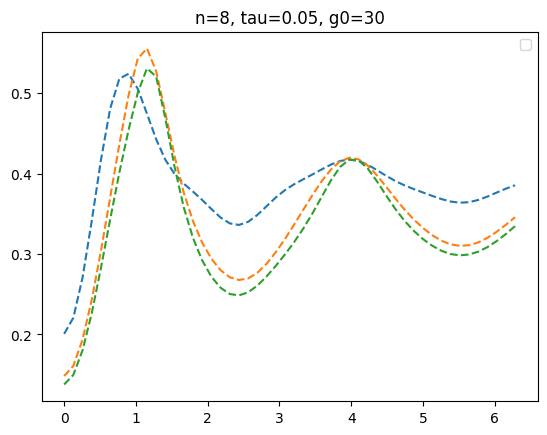

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32148/3581361306.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


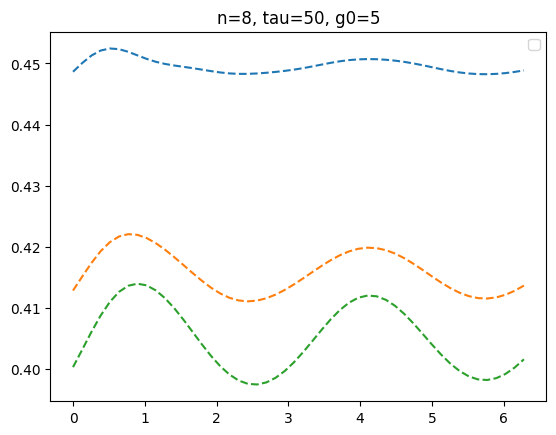

In [266]:
tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi = groundstate(g0, L)

for i, n in enumerate(ns):

    for gf in gfs:

        states_j = free_states[(tau, gf)]
        t = free_times[(tau, gf)]
        t = t - t[0]

        #y = dat1[(tau, gf)][i]   # <- dictionary indexing

        #plot(t, -np.log(y)/n, label=f"gf={gf}")

        x= dat2[(tau, gf)][i]
        plot(t, -log(x)/n, "--")

    title(f"n={n}, tau={tau}, g0={g0}")
    legend()
    #show()
show()

tau_index = -1
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi = groundstate(g0, L)

for i, n in enumerate(ns):

    for gf in gfs:

        states_j = free_states[(tau, gf)]
        t = free_times[(tau, gf)]
        t = t - t[0]


        #plot(t, -np.log(y)/n, label=f"gf={gf}")

        x= dat2[(tau, gf)][i]
        plot(t, -log(x)/n, "--")

    title(f"n={n}, tau={tau}, g0={g0}")
    legend()
    #show()

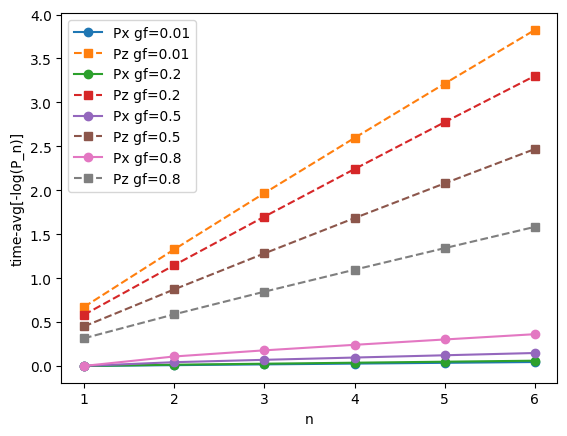

In [56]:
tau_index = -1
tau = taus_free[tau_index]
g0 = g0s[tau_index]

avg_x = {gf: [] for gf in gfs}
avg_z = {gf: [] for gf in gfs}

for gf in gfs:

    t = free_times[(tau, gf)]
    t = t - t[0]

    for i, n in enumerate(ns):

        y = dat1[(tau, gf)][i]   # Px
        x = dat2[(tau, gf)][i]   # Pz

        rx = -np.log(2*y)
        rz = -np.log(x)

        avg_x[gf].append(np.mean(rx))
        avg_z[gf].append(np.mean(rz))

# convert to arrays
for gf in gfs:
    avg_x[gf] = np.array(avg_x[gf])
    avg_z[gf] = np.array(avg_z[gf])

# ---- plot ----
for gf in gfs:
    plt.plot(ns, avg_x[gf], "o-", label=f"Px gf={gf}")
    plt.plot(ns, avg_z[gf], "s--", label=f"Pz gf={gf}")

plt.xlabel("n")
plt.ylabel("time-avg[-log(P_n)]")
plt.legend()
plt.show()

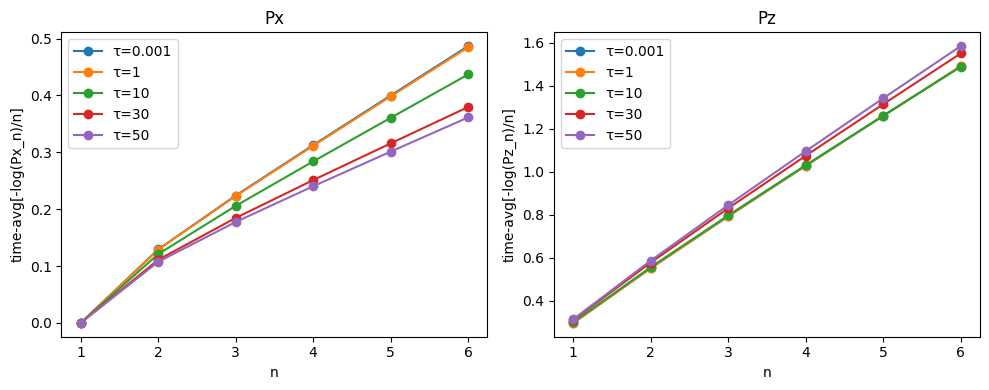

In [49]:
# ---- time-average vs n for all taus ----

avg_x_tau = {}
avg_z_tau = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        avg_x = []
        avg_z = []

        for i, n in enumerate(ns):

            t = free_times[(tau, gf)]
            t = t - t[0]

            y = dat1[(tau, gf)][i]   # Px
            x = dat2[(tau, gf)][i]   # Pz

            rx = -np.log(2*y)
            rz = -np.log(x)

            avg_x.append(np.mean(rx))
            avg_z.append(np.mean(rz))

        avg_x_tau[tau] = np.array(avg_x)
        avg_z_tau[tau] = np.array(avg_z)


# ---- plotting ----
plt.figure(figsize=(10,4))

# Px
plt.subplot(1,2,1)
for tau in taus_free:
    plt.plot(ns, avg_x_tau[tau], marker="o", label=f"τ={tau}")
plt.xlabel("n")
plt.ylabel("time-avg[-log(Px_n)/n]")
plt.title("Px")
plt.legend()

# Pz
plt.subplot(1,2,2)
for tau in taus_free:
    plt.plot(ns, avg_z_tau[tau], marker="o", label=f"τ={tau}")
plt.xlabel("n")
plt.ylabel("time-avg[-log(Pz_n)/n]")
plt.title("Pz")
plt.legend()

plt.tight_layout()
plt.show()

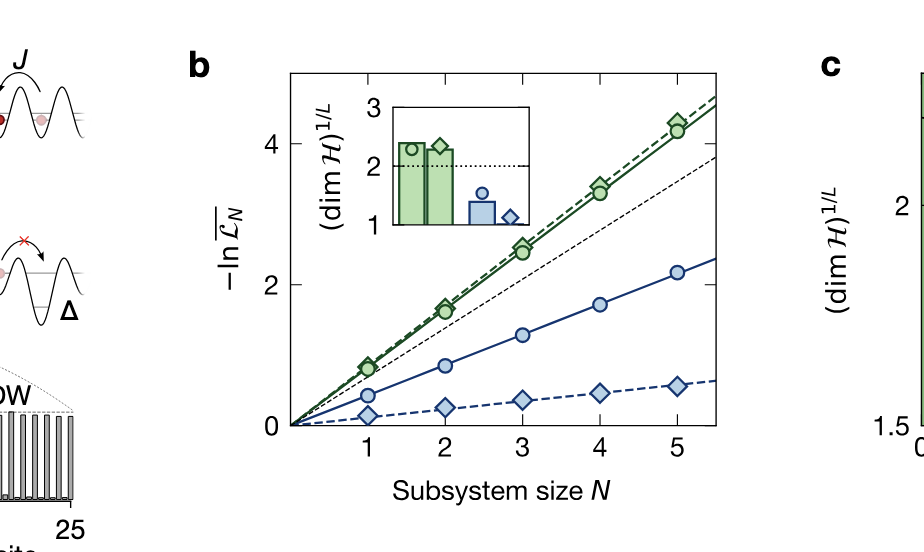

In [3]:
import numpy as np

def tfim_energy_variance(state, g):
    
    u, v, k = state
    
    u = np.asarray(u)
    v = np.asarray(v)
    k = np.asarray(k)

    eps = 2*np.sqrt((g - np.cos(k))**2 + np.sin(k)**2)

    nk = np.abs(v)**2

    variance = np.sum((eps**2) * nk * (1 - nk))

    return variance


In [71]:
import numpy as np

def energy_variance(state, g):
    g=-g
    u, v, k = state
    u = np.asarray(u)
    v = np.asarray(v)
    k = np.asarray(k)

    a = 2*(g - np.cos(k))
    b = 2*np.sin(k)

    eps2 = a**2 + b**2

    Ek = a*(np.abs(u)**2 - np.abs(v)**2) - 2*b*np.imag(np.conj(u)*v)

    var = np.sum(eps2 - Ek**2)

    return np.real(var)

import numpy as np

import numpy as np

def von_neumann_entropy(state, g):
    g = -g
    u, v, k = state
    u = np.asarray(u)
    v = np.asarray(v)
    k = np.asarray(k)

    a = 2*(g - np.cos(k))
    b = 2*np.sin(k)

    eps = np.sqrt(a**2 + b**2)

    Ek = a*(np.abs(u)**2 - np.abs(v)**2) - 2*b*np.imag(np.conj(u)*v)

    p = 0.5*(1 + Ek/eps)   # excited-state occupation of H(g)

    eps_clip = 1e-15
    p = np.clip(p, eps_clip, 1 - eps_clip)

    S = -np.sum(p*np.log(p) + (1-p)*np.log(1-p))
    return np.real(S)

In [36]:
import analytical_quench_states as kz

In [78]:
x=groundstate(10,L)
von_neumann_entropy(x,10)

np.float64(1.0653350999070316e-11)

In [74]:
taus = logspace(-2,2,20)
qs = [kz.state(100,tau,tau) for tau in taus]

In [75]:
x= groundstate(10,100)


E=[energy_variance(q,0) for q in qs]
S = array([von_neumann_entropy(s,0) for s in qs])

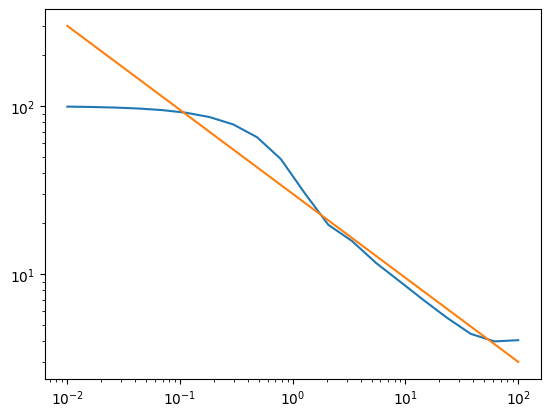

[]

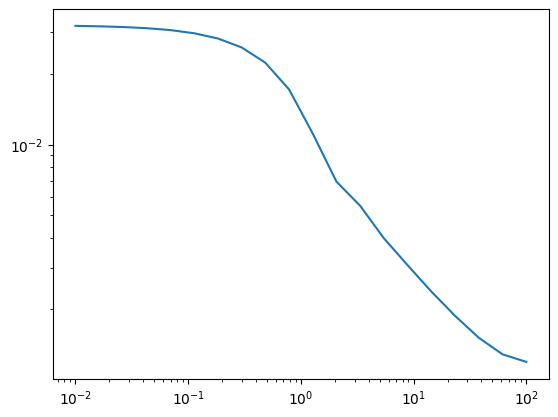

In [80]:
plot(taus,E)
plot(taus,taus**(-1/2)*30)
loglog()
show()

plot(taus,S/L)
loglog()

In [126]:
def entropyvec(states,gf):
    return array([von_neumann_entropy(state,gf) for state in states])


In [178]:
taus_free = [0.001, 1,5, 10]
g0s = [30, 10, 5, 5,5]
gfs = [.5]
L = 600

free_states = {}
free_times = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        states, t_eval = free_evo_states(tau, gf, g0, L)

        free_states[(tau, gf)] = states
        free_times[(tau, gf)] = t_eval

g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5


In [179]:

dat = {}   # Px

for (tau, gf), states_j in free_states.items():
    dat[(tau, gf)] = entropyvec(states_j,gf)
print("Done!")



Done!


In [180]:
# ---- compute P_n data ----
datP = {}

for n in [2,3,4,5,6]:
    tmp = {}
    for (tau, gf), states_j in free_states.items():
        tmp[(tau, gf)] = P_vector(n, states_j)
    datP[n] = tmp

print("P_n done")
datPz = {}

for n in [1,2,3,4,5,6]:
    tmp = {}
    for (tau, gf), states_j in free_states.items():
        tmp[(tau, gf)] = Pz_vector(n, states_j)
    datPz[n] = tmp

print("P_n done")


P_n done
P_n done


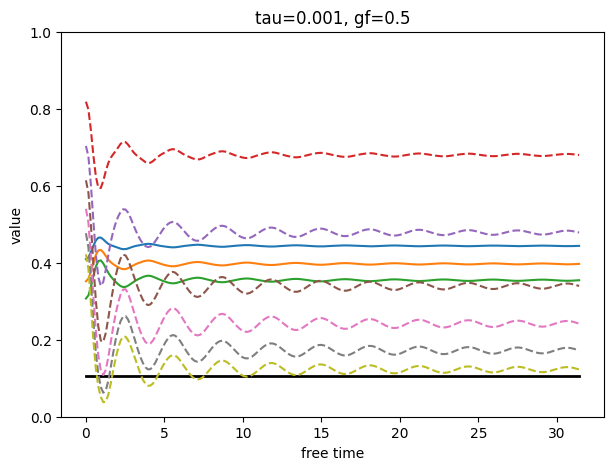

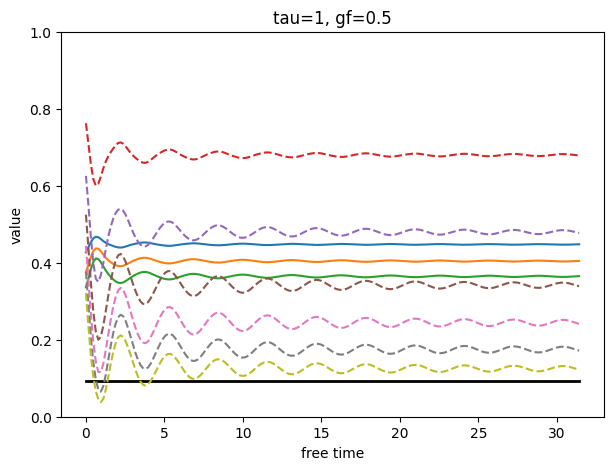

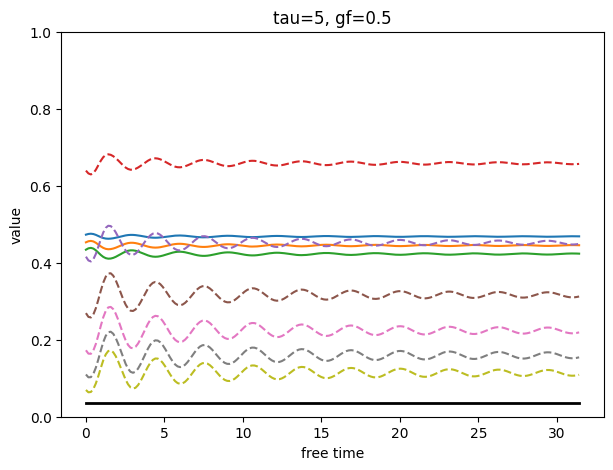

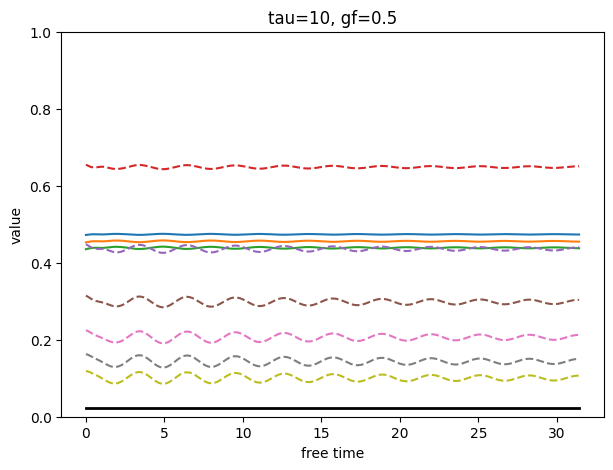

In [181]:
import matplotlib.pyplot as plt
import numpy as np

for (tau, gf), S in dat.items():
    t = free_times[(tau, gf)]
    t = t - t[0]

    plt.figure(figsize=(7,5))

    # entropy
    plt.plot(t, S/L, "k", lw=2, label="Entropy")

    # Px_n
    for n in [2,3,4]:
        Pn = datP[n][(tau, gf)]
        plt.plot(t, (Pn), label=f"Px{n}")

    # Pz_n
    for n in [1,2,3,4,5,6]:
        Pnz = datPz[n][(tau, gf)]
        plt.plot(t, (Pnz), "--", label=f"Pz{n}")

    plt.xlabel("free time")
    plt.ylabel("value")
    plt.title(f"tau={tau}, gf={gf}")
    #plt.legend()
    ylim(0,1)
    plt.show()

In [158]:
u=kz.state(L,100,-1000)[0]
state = kz.state(L,100,-1000)
u = state[0]
v = state[1]

In [159]:
1-sum(np.abs(u)**2)/L*2

np.float64(0.9989653358007425)

In [160]:
op.Pz_n(1,state)

np.complex128(0.9989653358007426+0j)

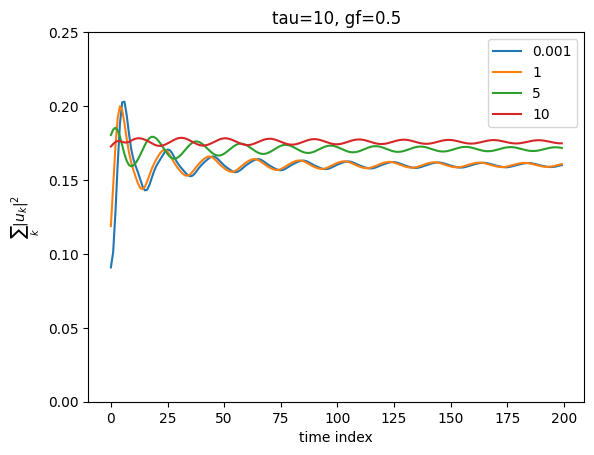

In [169]:
import numpy as np
import matplotlib.pyplot as plt

for (tau, gf), states_j in free_states.items():

    u2_sum = []

    for s in states_j:
        u, v, k = s
        u2_sum.append(np.sum(np.abs(u)**2))

    u2_sum = np.array(u2_sum)/L

    plt.plot(u2_sum,label=tau)
    legend()

    plt.xlabel("time index")
    plt.ylabel(r"$\sum_k |u_k|^2$")
    plt.title(f"tau={tau}, gf={gf}")
    ylim(0,.25)


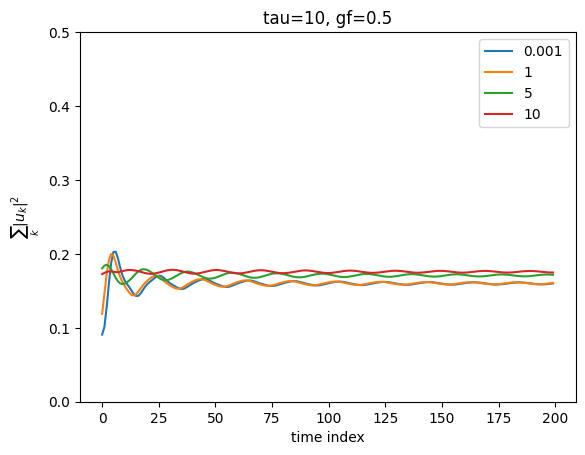

In [177]:
import numpy as np
import matplotlib.pyplot as plt

for (tau, gf), states_j in free_states.items():

    u2_sum = []
    s2_sum = []

    for s in states_j:

        u, v, k = s
        u2_sum.append(np.sum(np.abs(u)**2))
        s2_sum.append( op.sz_correlation([0,1],s))

    u2_sum = np.array(u2_sum)/L

    plt.plot(u2_sum,label=tau)
    #plot(s2_sum,label=tau)
    legend()

    plt.xlabel("time index")
    plt.ylabel(r"$\sum_k |u_k|^2$")
    plt.title(f"tau={tau}, gf={gf}")
    ylim(0,.5)


In [ ]:
op.sz_correlation([0,2])